# Prediction of Age at First Breast Cancer Diagnosis Using Machine Learning Regression Models

### A Comparative Study Using NHANES (1988–2018)

**Submitted By:** Nimisha Singh  
**Mentor:** Dr. Piyush Sewal  
**Course:** B.Sc. Information Technology (5th Semester)  
**Subject:** Machine Learning  
**Dataset:** National Health and Nutrition Examination Survey (NHANES)  
**Target Variable:** MCQ240E – Age at First Breast Cancer Diagnosis  
**Institution:** Amity School of Engineering and Technology (ASET),  
Amity University Punjab, Mohali

## 1. Project Objective

The objective of this project is to investigate whether selected demographic, socioeconomic, and mortality-related variables from the National Health and Nutrition Examination Survey (NHANES) can be used to estimate age at first breast cancer diagnosis. The study uses the age at first breast cancer diagnosis recorded in the Medical Conditions questionnaire as the target variable. Eight regression algorithms are compared using the same training and testing data to identify the model that provides the strongest predictive performance.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    explained_variance_score
)

import warnings
warnings.filterwarnings("ignore")

print("All required libraries imported successfully.")

All required libraries imported successfully.


In [2]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles and folders available:")
for item in os.listdir():
    print(item)

Current working directory:
C:\Users\nimis

Files and folders available:
.anaconda
.conda
.continuum
.copilot
.idlerc
.ipynb_checkpoints
.ipython
.jupyter
.matplotlib
.vscode
.vscode-shared
anaconda3
anaconda_projects
AppData
Application Data
BREAST CANCER.ipynb
Breast_Cancer_NHANES_FINAL.ipynb
Contacts
Cookies
Documents
Downloads
Favorites
Links
Local Settings
Music
My Documents
NetHood
NTUSER.DAT
ntuser.dat.LOG1
ntuser.dat.LOG2
NTUSER.DAT{a058c03a-0227-11f0-b65f-30e3a4b39434}.TM.blf
NTUSER.DAT{a058c03a-0227-11f0-b65f-30e3a4b39434}.TMContainer00000000000000000001.regtrans-ms
NTUSER.DAT{a058c03a-0227-11f0-b65f-30e3a4b39434}.TMContainer00000000000000000002.regtrans-ms
ntuser.ini
OneDrive
PrintHood
Recent
Saved Games
scikit_learn_data
Searches
SendTo
Start Menu
Templates
Untitled1.ipynb
Untitled2.ipynb
Untitled3.ipynb
VERIFY.ipynb
Videos


In [3]:
import os

search_locations = [
    r"C:\Users\nimis\OneDrive\Desktop",
    r"C:\Users\nimis\Downloads",
    r"C:\Users\nimis\Documents"
]

print("Searching for NHANES CSV files...\n")

for folder in search_locations:
    if os.path.exists(folder):
        print(f"\n--- {folder} ---")
        for root, dirs, files in os.walk(folder):
            for file in files:
                if file.lower().endswith(".csv"):
                    print(os.path.join(root, file))

Searching for NHANES CSV files...


--- C:\Users\nimis\OneDrive\Desktop ---
C:\Users\nimis\OneDrive\Desktop\21743372\38575571_dictionary_drug_codes.csv
C:\Users\nimis\OneDrive\Desktop\21743372\38575574_dictionary_harmonized_categories.csv
C:\Users\nimis\OneDrive\Desktop\21743372\41730855_dictionary_drug_codes.csv
C:\Users\nimis\OneDrive\Desktop\21743372\41730858_dictionary_harmonized_categories.csv
C:\Users\nimis\OneDrive\Desktop\21743372\41730861_dictionary_nhanes.csv
C:\Users\nimis\OneDrive\Desktop\21743372\41731260_dictionary_nhanes.csv
C:\Users\nimis\OneDrive\Desktop\21743372\chemicals_clean.csv
C:\Users\nimis\OneDrive\Desktop\21743372\chemicals_unclean.csv
C:\Users\nimis\OneDrive\Desktop\21743372\comments_clean.csv
C:\Users\nimis\OneDrive\Desktop\21743372\comments_unclean.csv
C:\Users\nimis\OneDrive\Desktop\21743372\demographics_clean.csv
C:\Users\nimis\OneDrive\Desktop\21743372\demographics_unclean.csv
C:\Users\nimis\OneDrive\Desktop\21743372\dietary_clean.csv
C:\Users\nimis\OneD

In [4]:
# ============================================================
# STEP 6: LOAD NHANES DATASETS
# ============================================================

import pandas as pd
import os

data_path = r"C:\Users\nimis\OneDrive\Desktop\21743372"

questionnaire_path = os.path.join(data_path, "questionnaire_clean.csv")
demographics_path = os.path.join(data_path, "demographics_clean.csv")
mortality_path = os.path.join(data_path, "mortality_clean.csv")

questionnaire = pd.read_csv(questionnaire_path, low_memory=False)
demographics = pd.read_csv(demographics_path, low_memory=False)
mortality = pd.read_csv(mortality_path, low_memory=False)

print("Datasets loaded successfully.\n")

print("Questionnaire shape:", questionnaire.shape)
print("Demographics shape:", demographics.shape)
print("Mortality shape:", mortality.shape)

Datasets loaded successfully.

Questionnaire shape: (134515, 1445)
Demographics shape: (135310, 281)
Mortality shape: (135310, 16)


In [5]:
# ============================================================
# STEP 7: CHECK REQUIRED VARIABLES
# ============================================================

print("QUESTIONNAIRE")
print("=" * 60)

questionnaire_columns = [
    "SEQN",
    "MCQ220",
    "MCQ230A",
    "MCQ240E"
]

for col in questionnaire_columns:
    print(f"{col}: {col in questionnaire.columns}")

print("\nDEMOGRAPHICS")
print("=" * 60)

demographic_columns = [
    "SEQN",
    "RIDAGEYR",
    "RIAGENDR",
    "RIDRETH1",
    "DMDEDUC2",
    "DMDMARTL",
    "INDFMPIR"
]

for col in demographic_columns:
    print(f"{col}: {col in demographics.columns}")

print("\nMORTALITY")
print("=" * 60)

mortality_columns = [
    "SEQN",
    "MORTSTAT",
    "PERMTH_EXM"
]

for col in mortality_columns:
    print(f"{col}: {col in mortality.columns}")

QUESTIONNAIRE
SEQN: True
MCQ220: True
MCQ230A: True
MCQ240E: True

DEMOGRAPHICS
SEQN: True
RIDAGEYR: True
RIAGENDR: True
RIDRETH1: True
DMDEDUC2: True
DMDMARTL: True
INDFMPIR: True

MORTALITY
SEQN: True
MORTSTAT: True
PERMTH_EXM: True


In [6]:
# ============================================================
# STEP 8: INSPECT BREAST CANCER VARIABLES
# ============================================================

print("MCQ220 - Ever told you had cancer or malignancy")
print(questionnaire["MCQ220"].value_counts(dropna=False))

print("\nMCQ230A - Type of first cancer")
print(questionnaire["MCQ230A"].value_counts(dropna=False).sort_index())

print("\nMCQ240E - Age when breast cancer was first diagnosed")
print(questionnaire["MCQ240E"].describe())

MCQ220 - Ever told you had cancer or malignancy
MCQ220
2.0    69121
NaN    59388
1.0     5946
9.0       59
7.0        1
Name: count, dtype: int64

MCQ230A - Type of first cancer
MCQ230A
9.0          1
10.0       121
11.0        11
12.0        31
13.0        21
14.0       794
15.0       327
16.0       347
17.0        28
18.0         2
19.0        93
20.0        25
21.0        51
22.0        24
23.0       133
24.0       108
25.0       291
26.0        30
27.0         1
28.0       114
29.0        12
30.0       786
31.0        22
32.0       752
33.0       391
34.0        12
35.0        42
36.0        30
37.0        96
38.0       209
39.0       222
99.0        37
NaN     129351
Name: count, dtype: int64

MCQ240E - Age when breast cancer was first diagnosed
count      823.000000
mean      1028.726610
std       9811.499559
min         16.000000
25%         48.000000
50%         58.000000
75%         68.000000
max      99999.000000
Name: MCQ240E, dtype: float64


In [7]:
# ============================================================
# STEP 9: CREATE INITIAL BREAST CANCER COHORT
# ============================================================

# Select records where MCQ240E is available
breast_cancer = questionnaire[
    questionnaire["MCQ240E"].notna()
].copy()

print("Records with MCQ240E available:", len(breast_cancer))

# Display special/invalid values
print("\nMCQ240E values >= 900:")
print(
    breast_cancer.loc[
        breast_cancer["MCQ240E"] >= 900,
        "MCQ240E"
    ].value_counts()
)

Records with MCQ240E available: 823

MCQ240E values >= 900:
MCQ240E
99999.0    8
Name: count, dtype: int64


In [8]:
# ============================================================
# STEP 10: CLEAN MCQ240E TARGET VARIABLE
# ============================================================

# Keep only realistic ages at first breast cancer diagnosis
breast_cancer = breast_cancer[
    breast_cancer["MCQ240E"].between(1, 100)
].copy()

print("Valid breast cancer records:", len(breast_cancer))

print("\nMCQ240E summary after cleaning:")
print(breast_cancer["MCQ240E"].describe())

Valid breast cancer records: 815

MCQ240E summary after cleaning:
count    815.000000
mean      57.239264
std       13.724668
min       16.000000
25%       48.000000
50%       58.000000
75%       67.000000
max       85.000000
Name: MCQ240E, dtype: float64


In [9]:
# ============================================================
# STEP 11: VERIFY TARGET VARIABLE
# ============================================================

print("Target variable: MCQ240E")
print("Number of valid observations:", breast_cancer["MCQ240E"].notna().sum())
print("Number of unique participants:", breast_cancer["SEQN"].nunique())

print("\nTarget statistics:")
print(breast_cancer["MCQ240E"].describe())

print("\nFirst 10 target values:")
print(breast_cancer[["SEQN", "MCQ240E"]].head(10))

Target variable: MCQ240E
Number of valid observations: 815
Number of unique participants: 815

Target statistics:
count    815.000000
mean      57.239264
std       13.724668
min       16.000000
25%       48.000000
50%       58.000000
75%       67.000000
max       85.000000
Name: MCQ240E, dtype: float64

First 10 target values:
        SEQN  MCQ240E
33274   80.0     73.0
33288   94.0     56.0
33397  206.0     44.0
33428  237.0     75.0
33570  389.0     76.0
33657  481.0     61.0
33785  614.0     52.0
33835  666.0     66.0
33928  761.0     63.0
33980  817.0     63.0


In [10]:
# ============================================================
# STEP 12: SELECT DEMOGRAPHIC VARIABLES
# ============================================================

demographic_columns = [
    "SEQN",
    "RIDAGEYR",
    "RIAGENDR",
    "RIDRETH1",
    "DMDEDUC2",
    "DMDMARTL",
    "INDFMPIR"
]

demographics_selected = demographics[demographic_columns].copy()

print("Selected demographic dataset shape:", demographics_selected.shape)

print("\nSelected demographic columns:")
print(demographics_selected.columns.tolist())

Selected demographic dataset shape: (135310, 7)

Selected demographic columns:
['SEQN', 'RIDAGEYR', 'RIAGENDR', 'RIDRETH1', 'DMDEDUC2', 'DMDMARTL', 'INDFMPIR']


In [12]:
# ============================================================
# STEP 13A: INVESTIGATE DUPLICATE SEQN VALUES
# ============================================================

print("Total demographic rows:", len(demographics_selected))
print("Unique SEQN values:", demographics_selected["SEQN"].nunique())

duplicate_count = demographics_selected["SEQN"].duplicated(keep=False).sum()

print("Rows belonging to duplicated SEQN values:", duplicate_count)

print("\nNumber of duplicated SEQN values:")
print(
    demographics_selected.loc[
        demographics_selected["SEQN"].duplicated(keep=False),
        "SEQN"
    ].nunique()
)

Total demographic rows: 135310
Unique SEQN values: 101316
Rows belonging to duplicated SEQN values: 67988

Number of duplicated SEQN values:
33994


In [13]:
# ============================================================
# STEP 13B: INSPECT DEMOGRAPHIC DUPLICATES
# ============================================================

duplicate_seqns = demographics_selected.loc[
    demographics_selected["SEQN"].duplicated(keep=False),
    "SEQN"
].unique()

print("Number of duplicate SEQN values to inspect:", len(duplicate_seqns))

print("\nSample duplicate records:")
display(
    demographics_selected[
        demographics_selected["SEQN"].isin(duplicate_seqns)
    ]
    .sort_values("SEQN")
    .head(30)
)

Number of duplicate SEQN values to inspect: 33994

Sample duplicate records:


,SEQN,RIDAGEYR,RIAGENDR,RIDRETH1,DMDEDUC2,DMDMARTL,INDFMPIR
0,3,21,1,1,3.0,5.0,0.641
33996,3,10,2,3,NaN,NaN,1.470
1,4,32,2,1,4.0,1.0,4.803
33997,4,1,1,4,NaN,NaN,0.570
34000,7,59,2,4,2.0,1.0,NaN
20050,7,3,2,4,NaN,3.0,NaN
2,9,48,2,3,4.0,1.0,3.747
34002,9,11,2,4,NaN,NaN,NaN
34003,10,43,1,4,3.0,4.0,NaN
3,10,35,1,3,5.0,6.0,5.406


In [14]:
# ============================================================
# STEP 13C: CHECK SEQN STRUCTURE ACROSS DATASETS
# ============================================================

print("QUESTIONNAIRE")
print("Total rows:", len(questionnaire))
print("Unique SEQN:", questionnaire["SEQN"].nunique())
print("Duplicated SEQN rows:",
      questionnaire["SEQN"].duplicated(keep=False).sum())

print("\nDEMOGRAPHICS")
print("Total rows:", len(demographics))
print("Unique SEQN:", demographics["SEQN"].nunique())
print("Duplicated SEQN rows:",
      demographics["SEQN"].duplicated(keep=False).sum())

print("\nMORTALITY")
print("Total rows:", len(mortality))
print("Unique SEQN:", mortality["SEQN"].nunique())
print("Duplicated SEQN rows:",
      mortality["SEQN"].duplicated(keep=False).sum())

QUESTIONNAIRE
Total rows: 134515
Unique SEQN: 101316
Duplicated SEQN rows: 66398

DEMOGRAPHICS
Total rows: 135310
Unique SEQN: 101316
Duplicated SEQN rows: 67988

MORTALITY
Total rows: 135310
Unique SEQN: 101316
Duplicated SEQN rows: 67988


In [65]:
# STEP 13D: INITIAL SEQN-ONLY MATCHING CHECK
# NOTE: SEQN-only matching produces duplicate matches across
# survey cycles and is not used for the final dataset.
bc_seqn = set(breast_cancer["SEQN"])

demo_match = demographics_selected[
    demographics_selected["SEQN"].isin(bc_seqn)
]

mortality_match = mortality[
    mortality["SEQN"].isin(bc_seqn)
]

print("Breast cancer participants:", len(bc_seqn))

print("\nDemographic rows matching breast cancer SEQNs:",
      len(demo_match))

print("Unique matching demographic SEQNs:",
      demo_match["SEQN"].nunique())

print("\nMortality rows matching breast cancer SEQNs:",
      len(mortality_match))

print("Unique matching mortality SEQNs:",
      mortality_match["SEQN"].nunique())

Breast cancer participants: 815

Demographic rows matching breast cancer SEQNs: 1059
Unique matching demographic SEQNs: 815

Mortality rows matching breast cancer SEQNs: 1059
Unique matching mortality SEQNs: 815


In [16]:
# ============================================================
# STEP 13F: CHECK FOR NHANES SURVEY-CYCLE IDENTIFIERS
# ============================================================

possible_cycle_columns = [
    "SDDSRVYR",
    "SDMVPSU",
    "SDMVSTRA",
    "Year",
    "YEAR",
    "year",
    "cycle",
    "Cycle",
    "SURVEY_YEAR",
    "SURVEY_CYCLE"
]

for df_name, df in [
    ("Questionnaire", questionnaire),
    ("Demographics", demographics),
    ("Mortality", mortality)
]:
    print("\n" + "=" * 60)
    print(df_name)
    print("=" * 60)

    for col in possible_cycle_columns:
        if col in df.columns:
            print(f"FOUND: {col}")


Questionnaire
FOUND: SDDSRVYR

Demographics
FOUND: SDDSRVYR
FOUND: SDMVPSU
FOUND: SDMVSTRA

Mortality
FOUND: SDDSRVYR


In [17]:
# ============================================================
# STEP 13G: SEARCH COLUMN NAMES FOR CYCLE/YEAR INFORMATION
# ============================================================

for df_name, df in [
    ("Questionnaire", questionnaire),
    ("Demographics", demographics),
    ("Mortality", mortality)
]:
    print("\n" + "=" * 60)
    print(df_name)
    print("=" * 60)

    matching_columns = [
        col for col in df.columns
        if any(
            keyword in str(col).upper()
            for keyword in ["YEAR", "CYCLE", "SRV", "SURVEY"]
        )
    ]

    print(matching_columns)


Questionnaire
['SDDSRVYR']

Demographics
['SDDSRVYR']

Mortality
['SDDSRVYR']


In [18]:
# ============================================================
# STEP 13H: INSPECT NHANES SURVEY CYCLES
# ============================================================

for df_name, df in [
    ("Questionnaire", questionnaire),
    ("Demographics", demographics),
    ("Mortality", mortality)
]:
    print("\n" + "=" * 60)
    print(df_name)
    print("=" * 60)

    print(df["SDDSRVYR"].value_counts(dropna=False).sort_index())


Questionnaire
SDDSRVYR
-1     33199
 1      9965
 2     11039
 3     10122
 4     10348
 5     10149
 6     10537
 7      9756
 8     10175
 9      9971
 10     9254
Name: count, dtype: int64

Demographics
SDDSRVYR
-1     33994
 1      9965
 2     11039
 3     10122
 4     10348
 5     10149
 6     10537
 7      9756
 8     10175
 9      9971
 10     9254
Name: count, dtype: int64

Mortality
SDDSRVYR
-1     33994
 1      9965
 2     11039
 3     10122
 4     10348
 5     10149
 6     10537
 7      9756
 8     10175
 9      9971
 10     9254
Name: count, dtype: int64


In [19]:
# ============================================================
# STEP 13I: BREAST CANCER RECORDS BY SURVEY CYCLE
# ============================================================

print("Breast cancer records by NHANES survey cycle:")

print(
    breast_cancer["SDDSRVYR"]
    .value_counts(dropna=False)
    .sort_index()
)

Breast cancer records by NHANES survey cycle:
SDDSRVYR
1     63
2     72
3     67
4     77
5     93
6     95
7     67
8     99
9     84
10    98
Name: count, dtype: int64


In [21]:
# ============================================================
# STEP 13J: CREATE CORRECT COMBINED PARTICIPANT KEY
# ============================================================

# Recreate demographic selection INCLUDING SDDSRVYR
demographic_columns_with_cycle = [
    "SEQN",
    "SDDSRVYR",
    "RIDAGEYR",
    "RIAGENDR",
    "RIDRETH1",
    "DMDEDUC2",
    "DMDMARTL",
    "INDFMPIR"
]

demographics_check = demographics[
    demographic_columns_with_cycle
].copy()

# Create combined participant key:
# NHANES survey cycle + participant SEQN

breast_cancer_check = breast_cancer.copy()

breast_cancer_check["PARTICIPANT_KEY"] = (
    breast_cancer_check["SDDSRVYR"].astype(str)
    + "_"
    + breast_cancer_check["SEQN"].astype(str)
)

demographics_check["PARTICIPANT_KEY"] = (
    demographics_check["SDDSRVYR"].astype(str)
    + "_"
    + demographics_check["SEQN"].astype(str)
)

# Select mortality variables
mortality_check = mortality[
    ["SEQN", "SDDSRVYR", "MORTSTAT", "PERMTH_EXM"]
].copy()

mortality_check["PARTICIPANT_KEY"] = (
    mortality_check["SDDSRVYR"].astype(str)
    + "_"
    + mortality_check["SEQN"].astype(str)
)

print("Breast cancer rows:", len(breast_cancer_check))
print(
    "Unique breast cancer participant keys:",
    breast_cancer_check["PARTICIPANT_KEY"].nunique()
)

print("\nUnique demographic participant keys:",
      demographics_check["PARTICIPANT_KEY"].nunique())

print("Unique mortality participant keys:",
      mortality_check["PARTICIPANT_KEY"].nunique())

Breast cancer rows: 815
Unique breast cancer participant keys: 815

Unique demographic participant keys: 135310
Unique mortality participant keys: 135310


In [22]:
# ============================================================
# STEP 13K: VERIFY PARTICIPANT-KEY MATCHING
# ============================================================

bc_keys = set(breast_cancer_check["PARTICIPANT_KEY"])

demo_matches = demographics_check[
    demographics_check["PARTICIPANT_KEY"].isin(bc_keys)
]

mortality_matches = mortality_check[
    mortality_check["PARTICIPANT_KEY"].isin(bc_keys)
]

print("Breast cancer participant keys:", len(bc_keys))

print("\nDemographic matching rows:", len(demo_matches))
print(
    "Unique demographic matching keys:",
    demo_matches["PARTICIPANT_KEY"].nunique()
)

print("\nMortality matching rows:", len(mortality_matches))
print(
    "Unique mortality matching keys:",
    mortality_matches["PARTICIPANT_KEY"].nunique()
)

print("\nDuplicate demographic participant keys among matches:")
print(
    demo_matches["PARTICIPANT_KEY"]
    .duplicated()
    .sum()
)

print("\nDuplicate mortality participant keys among matches:")
print(
    mortality_matches["PARTICIPANT_KEY"]
    .duplicated()
    .sum()
)

Breast cancer participant keys: 815

Demographic matching rows: 0
Unique demographic matching keys: 0

Mortality matching rows: 0
Unique mortality matching keys: 0

Duplicate demographic participant keys among matches:
0

Duplicate mortality participant keys among matches:
0


In [23]:
# ============================================================
# STEP 13L: INSPECT BREAST CANCER IDENTIFIERS
# ============================================================

print("Breast cancer identifiers:")
display(
    breast_cancer[
        ["SEQN", "SDDSRVYR", "MCQ240E"]
    ].head(20)
)

Breast cancer identifiers:


,SEQN,SDDSRVYR,MCQ240E
33274,80.0,1,73.0
33288,94.0,1,56.0
33397,206.0,1,44.0
33428,237.0,1,75.0
33570,389.0,1,76.0
33657,481.0,1,61.0
33785,614.0,1,52.0
33835,666.0,1,66.0
33928,761.0,1,63.0
33980,817.0,1,63.0


In [24]:
# ============================================================
# STEP 13M: SEARCH THOSE IDENTIFIERS IN DEMOGRAPHICS
# ============================================================

sample_bc = breast_cancer[
    ["SEQN", "SDDSRVYR", "MCQ240E"]
].head(10)

for _, row in sample_bc.iterrows():

    seqn = row["SEQN"]
    cycle = row["SDDSRVYR"]

    print(
        f"\nSearching SEQN={seqn}, SDDSRVYR={cycle}"
    )

    result = demographics[
        (demographics["SEQN"] == seqn) &
        (demographics["SDDSRVYR"] == cycle)
    ]

    display(
        result[
            [
                "SEQN",
                "SDDSRVYR",
                "RIDAGEYR",
                "RIAGENDR",
                "RIDRETH1"
            ]
        ]
    )


Searching SEQN=80.0, SDDSRVYR=1.0


,SEQN,SDDSRVYR,RIDAGEYR,RIAGENDR,RIDRETH1
34073,80,1,75,2,4



Searching SEQN=94.0, SDDSRVYR=1.0


,SEQN,SDDSRVYR,RIDAGEYR,RIAGENDR,RIDRETH1
34087,94,1,61,2,4



Searching SEQN=206.0, SDDSRVYR=1.0


...

,SEQN,SDDSRVYR,RIDAGEYR,RIAGENDR,RIDRETH1
34659,666,1,67,2,1



Searching SEQN=761.0, SDDSRVYR=1.0


,SEQN,SDDSRVYR,RIDAGEYR,RIAGENDR,RIDRETH1
34754,761,1,67,2,3



Searching SEQN=817.0, SDDSRVYR=1.0


,SEQN,SDDSRVYR,RIDAGEYR,RIAGENDR,RIDRETH1
34810,817,1,80,2,4


In [25]:
# ============================================================
# STEP 13N: COMPARE SEQN-ONLY MATCHING
# ============================================================

sample_seqns = breast_cancer["SEQN"].head(10).tolist()

for seqn in sample_seqns:

    result = demographics[
        demographics["SEQN"] == seqn
    ]

    print(f"\nSEQN = {seqn}")
    
    display(
        result[
            [
                "SEQN",
                "SDDSRVYR",
                "RIDAGEYR",
                "RIAGENDR",
                "RIDRETH1"
            ]
        ]
    )


SEQN = 80.0


,SEQN,SDDSRVYR,RIDAGEYR,RIAGENDR,RIDRETH1
20086,80,-1,5,1,4
34073,80,1,75,2,4



SEQN = 94.0


,SEQN,SDDSRVYR,RIDAGEYR,RIAGENDR,RIDRETH1
20093,94,-1,12,1,1
34087,94,1,61,2,4



SEQN = 206.0


...

,SEQN,SDDSRVYR,RIDAGEYR,RIAGENDR,RIDRETH1
304,666,-1,18,1,4
34659,666,1,67,2,1



SEQN = 761.0


,SEQN,SDDSRVYR,RIDAGEYR,RIAGENDR,RIDRETH1
355,761,-1,48,2,1
34754,761,1,67,2,3



SEQN = 817.0


,SEQN,SDDSRVYR,RIDAGEYR,RIAGENDR,RIDRETH1
383,817,-1,50,2,5
34810,817,1,80,2,4


In [26]:
# ============================================================
# STEP 13O: NORMALIZE SEQN AND SDDSRVYR FOR MERGING
# ============================================================

def normalize_id(series):
    return pd.to_numeric(series, errors="coerce").astype("Int64")


# Breast cancer
breast_cancer_final = breast_cancer.copy()

breast_cancer_final["SEQN_KEY"] = normalize_id(
    breast_cancer_final["SEQN"]
)

breast_cancer_final["CYCLE_KEY"] = normalize_id(
    breast_cancer_final["SDDSRVYR"]
)


# Demographics
demographics_final = demographics[
    [
        "SEQN",
        "SDDSRVYR",
        "RIDAGEYR",
        "RIAGENDR",
        "RIDRETH1",
        "DMDEDUC2",
        "DMDMARTL",
        "INDFMPIR"
    ]
].copy()

demographics_final["SEQN_KEY"] = normalize_id(
    demographics_final["SEQN"]
)

demographics_final["CYCLE_KEY"] = normalize_id(
    demographics_final["SDDSRVYR"]
)


# Mortality
mortality_final = mortality[
    [
        "SEQN",
        "SDDSRVYR",
        "MORTSTAT",
        "PERMTH_EXM"
    ]
].copy()

mortality_final["SEQN_KEY"] = normalize_id(
    mortality_final["SEQN"]
)

mortality_final["CYCLE_KEY"] = normalize_id(
    mortality_final["SDDSRVYR"]
)


print("Breast cancer:")
print(breast_cancer_final[["SEQN_KEY", "CYCLE_KEY"]].head())

print("\nDemographics:")
print(demographics_final[["SEQN_KEY", "CYCLE_KEY"]].head())

print("\nMortality:")
print(mortality_final[["SEQN_KEY", "CYCLE_KEY"]].head())

Breast cancer:
       SEQN_KEY  CYCLE_KEY
33274        80          1
33288        94          1
33397       206          1
33428       237          1
33570       389          1

Demographics:
   SEQN_KEY  CYCLE_KEY
0         3         -1
1         4         -1
2         9         -1
3        10         -1
4        11         -1

Mortality:
   SEQN_KEY  CYCLE_KEY
0         1          1
1         2          1
2         3          1
3         4          1
4         5          1


In [27]:
# ============================================================
# STEP 13P: TEST NORMALIZED MATCHING
# ============================================================

bc_keys = breast_cancer_final[
    ["SEQN_KEY", "CYCLE_KEY"]
].drop_duplicates()

demo_keys = demographics_final[
    ["SEQN_KEY", "CYCLE_KEY"]
].drop_duplicates()

mortality_keys = mortality_final[
    ["SEQN_KEY", "CYCLE_KEY"]
].drop_duplicates()


demo_test = bc_keys.merge(
    demo_keys,
    on=["SEQN_KEY", "CYCLE_KEY"],
    how="left",
    indicator=True
)

mortality_test = bc_keys.merge(
    mortality_keys,
    on=["SEQN_KEY", "CYCLE_KEY"],
    how="left",
    indicator=True
)


print("Breast cancer unique keys:", len(bc_keys))

print("\nDemographic matches:")
print(demo_test["_merge"].value_counts())

print("\nMortality matches:")
print(mortality_test["_merge"].value_counts())

Breast cancer unique keys: 815

Demographic matches:
_merge
both          815
left_only       0
right_only      0
Name: count, dtype: int64

Mortality matches:
_merge
both          815
left_only       0
right_only      0
Name: count, dtype: int64


In [28]:
# ============================================================
# STEP 13Q: CHECK COMBINED KEY UNIQUENESS
# ============================================================

print("Breast cancer duplicate combined keys:",
      breast_cancer_final.duplicated(
          subset=["SEQN_KEY", "CYCLE_KEY"]
      ).sum())

print("Demographics duplicate combined keys:",
      demographics_final.duplicated(
          subset=["SEQN_KEY", "CYCLE_KEY"]
      ).sum())

print("Mortality duplicate combined keys:",
      mortality_final.duplicated(
          subset=["SEQN_KEY", "CYCLE_KEY"]
      ).sum())

Breast cancer duplicate combined keys: 0
Demographics duplicate combined keys: 0
Mortality duplicate combined keys: 0


In [29]:
# ============================================================
# STEP 13R: FINAL BREAST CANCER DATASET MERGE
# ============================================================

# Keep only the required demographic variables
demo_for_merge = demographics_final[
    [
        "SEQN_KEY",
        "CYCLE_KEY",
        "RIDAGEYR",
        "RIAGENDR",
        "RIDRETH1",
        "DMDEDUC2",
        "DMDMARTL",
        "INDFMPIR"
    ]
].copy()

# Keep only the required mortality variables
mortality_for_merge = mortality_final[
    [
        "SEQN_KEY",
        "CYCLE_KEY",
        "MORTSTAT",
        "PERMTH_EXM"
    ]
].copy()

# Merge breast cancer + demographics
breast_cancer_demo = breast_cancer_final.merge(
    demo_for_merge,
    on=["SEQN_KEY", "CYCLE_KEY"],
    how="left",
    validate="one_to_one"
)

print("After demographic merge:")
print("Shape:", breast_cancer_demo.shape)
print("Unique participants:",
      breast_cancer_demo[
          ["SEQN_KEY", "CYCLE_KEY"]
      ].drop_duplicates().shape[0])

# Merge mortality information
bc_final = breast_cancer_demo.merge(
    mortality_for_merge,
    on=["SEQN_KEY", "CYCLE_KEY"],
    how="left",
    validate="one_to_one"
)

print("\nAfter mortality merge:")
print("Shape:", bc_final.shape)
print("Unique participants:",
      bc_final[
          ["SEQN_KEY", "CYCLE_KEY"]
      ].drop_duplicates().shape[0])

After demographic merge:
Shape: (815, 1453)
Unique participants: 815

After mortality merge:
Shape: (815, 1455)
Unique participants: 815


In [30]:
# ============================================================
# STEP 13S: FINAL DATASET VERIFICATION
# ============================================================

print("=" * 60)
print("FINAL DATASET VERIFICATION")
print("=" * 60)

print("\nTotal rows:", len(bc_final))

print(
    "Unique participants:",
    bc_final[
        ["SEQN_KEY", "CYCLE_KEY"]
    ].drop_duplicates().shape[0]
)

print(
    "Duplicate participant keys:",
    bc_final.duplicated(
        subset=["SEQN_KEY", "CYCLE_KEY"]
    ).sum()
)

print(
    "\nMCQ240E missing:",
    bc_final["MCQ240E"].isna().sum()
)

print(
    "RIDAGEYR missing:",
    bc_final["RIDAGEYR"].isna().sum()
)

print(
    "RIAGENDR missing:",
    bc_final["RIAGENDR"].isna().sum()
)

print(
    "RIDRETH1 missing:",
    bc_final["RIDRETH1"].isna().sum()
)

print(
    "MORTSTAT missing:",
    bc_final["MORTSTAT"].isna().sum()
)

print(
    "PERMTH_EXM missing:",
    bc_final["PERMTH_EXM"].isna().sum()
)

print("\nFinal columns:")
print(bc_final.columns.tolist())

FINAL DATASET VERIFICATION

Total rows: 815
Unique participants: 815
Duplicate participant keys: 0

MCQ240E missing: 0
RIDAGEYR missing: 0
RIAGENDR missing: 0
RIDRETH1 missing: 0
MORTSTAT missing: 0
PERMTH_EXM missing: 54

Final columns:
['Unnamed: 0', 'SEQN', 'SEQN_new', 'SDDSRVYR', 'AGQ030', 'ALQ101', 'ALQ110', 'ALQ111', 'ALQ120Q', 'ALQ120U', 'ALQ130', 'ALQ141Q', 'ALQ141U', 'ALQ151', 'ALQ155', 'ALQ160', 'ALQ170', 'ALQ270', 'ALQ280', 'ALQ290', 'BPD035', 'BPD058', 'BPD110A', 'BPD110B', 'BPD110C', 'BPD120', 'BPD130', 'BPD140', 'BPQ010', 'BPQ020', 'BPQ030', 'BPQ040A', 'BPQ040B', 'BPQ040C', 'BPQ040D', 'BPQ040E', 'BPQ040F', 'BPQ043A', 'BPQ043B', 'BPQ043C', 'BPQ043D', 'BPQ050A', 'BPQ050B', 'BPQ050C', 'BPQ050D', 'BPQ050E', 'BPQ052', 'BPQ056', 'BPQ057', 'BPQ059', 'BPQ060', 'BPQ070', 'BPQ080', 'BPQ090A', 'BPQ090B', 'BPQ090C', 'BPQ090D', 'BPQ100A', 'BPQ100B', 'BPQ100C', 'BPQ100D', 'DID040', 'DID040G', 'DID040Q', 'DID250', 'DID270', 'DID310D', 'DID310S', 'DID320', 'DID330', 'DID341', 'DID350', '

In [31]:
# ============================================================
# STEP 13T: VIEW FINAL DATASET
# ============================================================

display(
    bc_final[
        [
            "SEQN_KEY",
            "CYCLE_KEY",
            "MCQ240E",
            "RIDAGEYR",
            "RIAGENDR",
            "RIDRETH1",
            "DMDEDUC2",
            "DMDMARTL",
            "INDFMPIR",
            "MORTSTAT",
            "PERMTH_EXM"
        ]
    ].head(10)
)

,SEQN_KEY,CYCLE_KEY,MCQ240E,RIDAGEYR,RIAGENDR,RIDRETH1,DMDEDUC2,DMDMARTL,INDFMPIR,MORTSTAT,PERMTH_EXM
0,80,1,73.0,75,2,4,1.0,2.0,NaN,1.0,170.0
1,94,1,56.0,61,2,4,3.0,1.0,4.44,0.0,243.0
2,206,1,44.0,50,2,4,3.0,NaN,5.00,0.0,233.0
3,237,1,75.0,81,2,3,5.0,2.0,NaN,1.0,117.0
4,389,1,76.0,81,2,3,3.0,1.0,5.00,1.0,193.0
5,481,1,61.0,63,2,1,1.0,1.0,1.63,0.0,241.0
6,614,1,52.0,66,2,3,3.0,NaN,2.14,1.0,188.0
7,666,1,66.0,67,2,1,4.0,3.0,2.06,0.0,239.0
8,761,1,63.0,67,2,3,3.0,NaN,NaN,1.0,141.0
9,817,1,63.0,80,2,4,5.0,3.0,NaN,1.0,NaN


In [32]:
# ============================================================
# STEP 14: CREATE FINAL MODELING DATASET
# ============================================================

selected_columns = [
    "SEQN_KEY",
    "CYCLE_KEY",
    "RIDAGEYR",
    "RIAGENDR",
    "RIDRETH1",
    "DMDEDUC2",
    "DMDMARTL",
    "INDFMPIR",
    "MCQ240E",
    "MORTSTAT",
    "PERMTH_EXM"
]

model_df = bc_final[selected_columns].copy()

print("Model dataset shape:", model_df.shape)

print("\nModeling columns:")
print(model_df.columns.tolist())

display(model_df.head())

Model dataset shape: (815, 11)

Modeling columns:
['SEQN_KEY', 'CYCLE_KEY', 'RIDAGEYR', 'RIAGENDR', 'RIDRETH1', 'DMDEDUC2', 'DMDMARTL', 'INDFMPIR', 'MCQ240E', 'MORTSTAT', 'PERMTH_EXM']


,SEQN_KEY,CYCLE_KEY,RIDAGEYR,RIAGENDR,RIDRETH1,DMDEDUC2,DMDMARTL,INDFMPIR,MCQ240E,MORTSTAT,PERMTH_EXM
0,80,1,75,2,4,1.0,2.0,NaN,73.0,1.0,170.0
1,94,1,61,2,4,3.0,1.0,4.44,56.0,0.0,243.0
2,206,1,50,2,4,3.0,NaN,5.00,44.0,0.0,233.0
3,237,1,81,2,3,5.0,2.0,NaN,75.0,1.0,117.0
4,389,1,81,2,3,3.0,1.0,5.00,76.0,1.0,193.0


In [67]:
# ============================================================
# STEP 15: Target Variable Verification: Age at First Breast Cancer Diagnosis
# ============================================================

print("=" * 60)
print("TARGET VARIABLE VERIFICATION")
print("=" * 60)

print("\nTarget variable: MCQ240E")
print("Description: Age at first breast cancer diagnosis")

print("\nTotal records:", len(model_df))
print("Unique participants:", model_df["SEQN_KEY"].nunique())

print("\nMissing target values:")
print(model_df["MCQ240E"].isna().sum())

print("\nTarget summary:")
print(model_df["MCQ240E"].describe())

TARGET VARIABLE VERIFICATION

Target variable: MCQ240E
Description: Age at first breast cancer diagnosis

Total records: 815
Unique participants: 815

Missing target values:
0

Target summary:
count    815.000000
mean      57.239264
std       13.724668
min       16.000000
25%       48.000000
50%       58.000000
75%       67.000000
max       85.000000
Name: MCQ240E, dtype: float64


In [34]:
# ============================================================
# STEP 16: MISSING-VALUE ANALYSIS
# ============================================================

predictor_columns = [
    "RIDAGEYR",
    "RIAGENDR",
    "RIDRETH1",
    "DMDEDUC2",
    "DMDMARTL",
    "INDFMPIR",
    "MORTSTAT",
    "PERMTH_EXM"
]

missing_summary = pd.DataFrame({
    "Missing Count": model_df[predictor_columns].isna().sum(),
    "Missing Percentage": (
        model_df[predictor_columns]
        .isna()
        .mean()
        .mul(100)
        .round(2)
    )
})

print("Missing-value summary for predictors:")
display(missing_summary)

Missing-value summary for predictors:


,Missing Count,Missing Percentage
RIDAGEYR,0,0.00
RIAGENDR,0,0.00
RIDRETH1,0,0.00
DMDEDUC2,0,0.00
DMDMARTL,8,0.98
INDFMPIR,95,11.66
MORTSTAT,0,0.00
PERMTH_EXM,54,6.63


In [35]:
# ============================================================
# STEP 16B: CHECK UNIQUE VALUES OF CATEGORICAL VARIABLES
# ============================================================

categorical_columns = [
    "RIAGENDR",
    "RIDRETH1",
    "DMDEDUC2",
    "DMDMARTL",
    "MORTSTAT"
]

for column in categorical_columns:
    print("\n" + "=" * 60)
    print(column)
    print("=" * 60)
    print(model_df[column].value_counts(dropna=False).sort_index())


RIAGENDR
RIAGENDR
1      2
2    813
Name: count, dtype: int64

RIDRETH1
RIDRETH1
1     76
2     51
3    504
4    139
5     45
Name: count, dtype: int64

DMDEDUC2
DMDEDUC2
1.0     78
2.0    109
3.0    191
4.0    232
5.0    204
9.0      1
Name: count, dtype: int64

DMDMARTL
DMDMARTL
1.0    360
2.0    248
3.0    114
4.0     24
5.0     44
6.0     17
NaN      8
Name: count, dtype: int64

MORTSTAT
MORTSTAT
0.0    522
1.0    293
Name: count, dtype: int64


In [36]:
# ============================================================
# STEP 16C: CHECK NUMERIC VARIABLES
# ============================================================

numeric_columns = [
    "RIDAGEYR",
    "INDFMPIR",
    "PERMTH_EXM"
]

print(model_df[numeric_columns].describe())

         RIDAGEYR    INDFMPIR  PERMTH_EXM
count  815.000000  720.000000  761.000000
mean    67.862577    2.709889   92.608410
std     12.089074    1.619281   59.488824
min     22.000000    0.000000    2.000000
25%     60.000000    1.260000   43.000000
50%     70.000000    2.360000   80.000000
75%     79.000000    4.410000  132.000000
max     85.000000    5.000000  248.000000


In [37]:
# ============================================================
# STEP 17: CLEAN NHANES SPECIAL MISSING CODES
# ============================================================

model_clean = model_df.copy()

# NHANES "Don't know" code in education
# Treat it as missing rather than as a real education category.
model_clean["DMDEDUC2"] = model_clean["DMDEDUC2"].replace(
    {9: np.nan}
)

# Display the updated missing-value counts
print("Missing values after cleaning special NHANES codes:")
print(model_clean.isna().sum())

Missing values after cleaning special NHANES codes:
SEQN_KEY       0
CYCLE_KEY      0
RIDAGEYR       0
RIAGENDR       0
RIDRETH1       0
DMDEDUC2       1
DMDMARTL       8
INDFMPIR      95
MCQ240E        0
MORTSTAT       0
PERMTH_EXM    54
dtype: int64


In [38]:
# ============================================================
# STEP 18: DEFINE PREDICTORS AND TARGET
# ============================================================

target_column = "MCQ240E"

feature_columns = [
    "RIDAGEYR",
    "RIAGENDR",
    "RIDRETH1",
    "DMDEDUC2",
    "DMDMARTL",
    "INDFMPIR",
    "MORTSTAT",
    "PERMTH_EXM"
]

X = model_clean[feature_columns].copy()
y = model_clean[target_column].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(feature_columns)

print("\nTarget:")
print(target_column)

Feature matrix shape: (815, 8)
Target shape: (815,)

Features:
['RIDAGEYR', 'RIAGENDR', 'RIDRETH1', 'DMDEDUC2', 'DMDMARTL', 'INDFMPIR', 'MORTSTAT', 'PERMTH_EXM']

Target:
MCQ240E


### Selected Predictors Used for Model Development

The predictor variables were selected from the demographic and mortality-related information available in the NHANES dataset. The selected variables represent demographic, socioeconomic, and mortality-related characteristics that were used to examine their relationship with the target variable, **MCQ240E (Age at First Breast Cancer Diagnosis)**.

The eight predictor variables used for regression modelling were **RIDAGEYR (current age), RIAGENDR (sex), RIDRETH1 (race/ethnicity), DMDEDUC2 (education level), DMDMARTL (marital status), INDFMPIR (income-to-poverty ratio), MORTSTAT (mortality status), and PERMTH_EXM (mortality follow-up duration)**.

The target variable for this study is **MCQ240E**, which represents the reported age at which breast cancer was first diagnosed. The same eight predictors and the same preprocessing procedure were used across all eight regression algorithms to ensure a consistent comparison of model performance.

The final feature matrix contains **815 observations and 8 predictor variables**, while the target vector contains **815 valid observations**. Mortality-related variables, particularly mortality follow-up duration, are treated as modelling variables in this study. Because these variables may have a temporal relationship with diagnosis history, they should not be interpreted as causal predictors or as information that would necessarily have been available at the time of diagnosis. This consideration is addressed in the limitations of the study.

In [39]:
# ============================================================
# STEP 19: TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training observations:", X_train.shape[0])
print("Testing observations:", X_test.shape[0])

print("\nTraining target observations:", y_train.shape[0])
print("Testing target observations:", y_test.shape[0])

Training observations: 652
Testing observations: 163

Training target observations: 652
Testing target observations: 163


In [40]:
# ============================================================
# STEP 20: PREPROCESSING PIPELINE
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

numeric_features = [
    "RIDAGEYR",
    "INDFMPIR",
    "PERMTH_EXM"
]

categorical_features = [
    "RIAGENDR",
    "RIDRETH1",
    "DMDEDUC2",
    "DMDMARTL",
    "MORTSTAT"
]

# Numerical preprocessing:
# Missing values -> median
# Scaling -> StandardScaler
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median",
                add_indicator=True
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

# Categorical preprocessing:
# Missing values -> most frequent category
# Convert categories into numerical dummy variables
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [41]:
# ============================================================
# STEP 21: VERIFY TRAINING AND TESTING DATA
# ============================================================

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nMissing values in X_train:")
print(X_train.isna().sum())

print("\nMissing values in X_test:")
print(X_test.isna().sum())

print("\ny_train summary:")
print(y_train.describe())

print("\ny_test summary:")
print(y_test.describe())

X_train shape: (652, 8)
X_test shape: (163, 8)

Missing values in X_train:
RIDAGEYR       0
RIAGENDR       0
RIDRETH1       0
DMDEDUC2       1
DMDMARTL       7
INDFMPIR      80
MORTSTAT       0
PERMTH_EXM    41
dtype: int64

Missing values in X_test:
RIDAGEYR       0
RIAGENDR       0
RIDRETH1       0
DMDEDUC2       0
DMDMARTL       1
INDFMPIR      15
MORTSTAT       0
PERMTH_EXM    13
dtype: int64

y_train summary:
count    652.000000
mean      57.929448
std       13.698574
min       16.000000
25%       48.000000
50%       59.000000
75%       68.000000
max       85.000000
Name: MCQ240E, dtype: float64

y_test summary:
count    163.000000
mean      54.478528
std       13.521057
min       16.000000
25%       46.000000
50%       54.000000
75%       63.000000
max       85.000000
Name: MCQ240E, dtype: float64


In [42]:
# ============================================================
# STEP 22: DEFINE THE EIGHT REGRESSION MODELS
# ============================================================

models = {
    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(alpha=1.0),

    "Lasso Regression": Lasso(
        alpha=0.01,
        max_iter=10000
    ),

    "Decision Tree Regression": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest Regression": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting Regression": GradientBoostingRegressor(
        random_state=42
    ),

    "K-Nearest Neighbors Regression": KNeighborsRegressor(
        n_neighbors=5
    ),

    "Support Vector Regression": SVR(
        kernel="rbf",
        C=100,
        epsilon=0.1
    )
}

print("Number of regression models:", len(models))

for name in models:
    print("-", name)

Number of regression models: 8
- Linear Regression
- Ridge Regression
- Lasso Regression
- Decision Tree Regression
- Random Forest Regression
- Gradient Boosting Regression
- K-Nearest Neighbors Regression
- Support Vector Regression


In [43]:
# ============================================================
# STEP 23: CREATE MODEL PIPELINES
# ============================================================

model_pipelines = {}

for name, model in models.items():

    model_pipelines[name] = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

print("Model pipelines created successfully.")

for name in model_pipelines:
    print("-", name)

Model pipelines created successfully.
- Linear Regression
- Ridge Regression
- Lasso Regression
- Decision Tree Regression
- Random Forest Regression
- Gradient Boosting Regression
- K-Nearest Neighbors Regression
- Support Vector Regression


In [44]:
# ============================================================
# STEP 24: TRAIN ALL EIGHT MODELS
# ============================================================

trained_models = {}

for name, pipeline in model_pipelines.items():

    print(f"Training: {name}")

    pipeline.fit(X_train, y_train)

    trained_models[name] = pipeline

print("\nAll eight models trained successfully.")

Training: Linear Regression
Training: Ridge Regression
Training: Lasso Regression
Training: Decision Tree Regression
Training: Random Forest Regression
Training: Gradient Boosting Regression
Training: K-Nearest Neighbors Regression
Training: Support Vector Regression

All eight models trained successfully.


In [45]:
# ============================================================
# STEP 25: GENERATE TEST-SET PREDICTIONS
# ============================================================

predictions = {}

for name, pipeline in trained_models.items():

    predictions[name] = pipeline.predict(X_test)

print("Predictions generated for all models.")

for name, pred in predictions.items():
    print(
        f"{name}: {len(pred)} predictions"
    )

Predictions generated for all models.
Linear Regression: 163 predictions
Ridge Regression: 163 predictions
Lasso Regression: 163 predictions
Decision Tree Regression: 163 predictions
Random Forest Regression: 163 predictions
Gradient Boosting Regression: 163 predictions
K-Nearest Neighbors Regression: 163 predictions
Support Vector Regression: 163 predictions


In [66]:
# ============================================================
# STEP 26: CALCULATE MODEL PERFORMANCE METRICS
# ============================================================

results = []

for name, y_pred in predictions.items():

    mae = mean_absolute_error(y_test, y_pred)

    mse = mean_squared_error(y_test, y_pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, y_pred)

    mape = np.mean(
        np.abs(
            (y_test.values - y_pred)
            / y_test.values
        )
    ) * 100

    explained_variance = explained_variance_score(
        y_test,
        y_pred
    )

    # Project-defined derived accuracy measure
    derived_accuracy = (1 - (mape / 100)) * 100

    results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "MAPE": mape,
        "Explained Variance": explained_variance,
        "MAPE-Derived Score (%)": derived_accuracy
    })

results_df = pd.DataFrame(results)

print("Model evaluation completed.")

display(
    results_df.round(4)
)

Model evaluation completed.


,Model,MAE,MSE,RMSE,R2,MAPE,Explained Variance,MAPE-Derived Score (%)
0,Linear Regression,7.3861,111.2699,10.5485,0.3876,16.9488,0.4037,83.0512
1,Ridge Regression,7.3773,111.0707,10.5390,0.3887,16.9357,0.4050,83.0643
2,Lasso Regression,7.3641,110.8524,10.5286,0.3899,16.9118,0.4064,83.0882
3,Decision Tree Regression,9.4110,173.4479,13.1700,0.0454,21.0838,0.0980,78.9162
4,Random Forest Regression,7.8934,121.1950,11.0089,0.3330,18.1327,0.3479,81.8673
5,Gradient Boosting Regression,7.6122,118.8486,10.9018,0.3459,17.6185,0.3610,82.3815
6,K-Nearest Neighbors Regression,8.9632,147.5811,12.1483,0.1878,20.8054,0.2511,79.1946
7,Support Vector Regression,8.1915,144.4865,12.0203,0.2048,19.2854,0.2800,80.7146


In [47]:
# ============================================================
# STEP 27: RANK MODELS
# ============================================================

results_ranked = results_df.sort_values(
    by="R2",
    ascending=False
).reset_index(drop=True)

print("Models ranked by R²:")
display(
    results_ranked.round(4)
)

Models ranked by R²:


,Model,MAE,MSE,RMSE,R2,MAPE,Explained Variance,Derived Accuracy (%)
0,Lasso Regression,7.3641,110.8524,10.5286,0.3899,16.9118,0.4064,83.0882
1,Ridge Regression,7.3773,111.0707,10.5390,0.3887,16.9357,0.4050,83.0643
2,Linear Regression,7.3861,111.2699,10.5485,0.3876,16.9488,0.4037,83.0512
3,Gradient Boosting Regression,7.6122,118.8486,10.9018,0.3459,17.6185,0.3610,82.3815
4,Random Forest Regression,7.8934,121.1950,11.0089,0.3330,18.1327,0.3479,81.8673
5,Support Vector Regression,8.1915,144.4865,12.0203,0.2048,19.2854,0.2800,80.7146
6,K-Nearest Neighbors Regression,8.9632,147.5811,12.1483,0.1878,20.8054,0.2511,79.1946
7,Decision Tree Regression,9.4110,173.4479,13.1700,0.0454,21.0838,0.0980,78.9162


In [48]:
# ============================================================
# STEP 28: 5-FOLD CROSS-VALIDATION ON TRAINING DATA
# ============================================================

from sklearn.model_selection import KFold, cross_val_score

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for name, pipeline in model_pipelines.items():

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="r2"
    )

    cv_results.append({
        "Model": name,
        "CV Mean R2": scores.mean(),
        "CV Std R2": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df.sort_values(
    by="CV Mean R2",
    ascending=False
).reset_index(drop=True)

print("5-Fold Cross-Validation Results:")
display(cv_results_df.round(4))

5-Fold Cross-Validation Results:


,Model,CV Mean R2,CV Std R2
0,Lasso Regression,0.4780,0.0829
1,Ridge Regression,0.4771,0.0830
2,Linear Regression,0.4765,0.0837
3,Random Forest Regression,0.4301,0.0949
4,Gradient Boosting Regression,0.3784,0.1109
5,K-Nearest Neighbors Regression,0.3152,0.0646
6,Support Vector Regression,0.2886,0.1106
7,Decision Tree Regression,-0.1472,0.2684


In [49]:
# ============================================================
# STEP 29: COMPARE TEST AND CROSS-VALIDATION PERFORMANCE
# ============================================================

comparison_df = results_df[
    ["Model", "R2", "MAE", "RMSE"]
].merge(
    cv_results_df,
    on="Model"
)

comparison_df = comparison_df.sort_values(
    by="R2",
    ascending=False
).reset_index(drop=True)

comparison_df = comparison_df.rename(
    columns={
        "R2": "Test R2",
        "MAE": "Test MAE",
        "RMSE": "Test RMSE"
    }
)

display(comparison_df.round(4))

,Model,Test R2,Test MAE,Test RMSE,CV Mean R2,CV Std R2
0,Lasso Regression,0.3899,7.3641,10.5286,0.4780,0.0829
1,Ridge Regression,0.3887,7.3773,10.5390,0.4771,0.0830
2,Linear Regression,0.3876,7.3861,10.5485,0.4765,0.0837
3,Gradient Boosting Regression,0.3459,7.6122,10.9018,0.3784,0.1109
4,Random Forest Regression,0.3330,7.8934,11.0089,0.4301,0.0949
5,Support Vector Regression,0.2048,8.1915,12.0203,0.2886,0.1106
6,K-Nearest Neighbors Regression,0.1878,8.9632,12.1483,0.3152,0.0646
7,Decision Tree Regression,0.0454,9.4110,13.1700,-0.1472,0.2684


In [68]:
# ============================================================
# STEP 30: FINAL MODEL COMPARISON TABLE
# ============================================================

final_results = results_df.merge(
    cv_results_df,
    on="Model"
)

final_results = final_results[
    [
        "Model",
        "MAE",
        "MSE",
        "RMSE",
        "R2",
        "MAPE",
        "Explained Variance",
        "MAPE-Derived Score (%)",
        "CV Mean R2",
        "CV Std R2"
    ]
].copy()

final_results = final_results.sort_values(
    by="R2",
    ascending=False
).reset_index(drop=True)

display(
    final_results.round(4)
)

,Model,MAE,MSE,RMSE,R2,MAPE,Explained Variance,MAPE-Derived Score (%),CV Mean R2,CV Std R2
0,Lasso Regression,7.3641,110.8524,10.5286,0.3899,16.9118,0.4064,83.0882,0.4780,0.0829
1,Ridge Regression,7.3773,111.0707,10.5390,0.3887,16.9357,0.4050,83.0643,0.4771,0.0830
2,Linear Regression,7.3861,111.2699,10.5485,0.3876,16.9488,0.4037,83.0512,0.4765,0.0837
3,Gradient Boosting Regression,7.6122,118.8486,10.9018,0.3459,17.6185,0.3610,82.3815,0.3784,0.1109
4,Random Forest Regression,7.8934,121.1950,11.0089,0.3330,18.1327,0.3479,81.8673,0.4301,0.0949
5,Support Vector Regression,8.1915,144.4865,12.0203,0.2048,19.2854,0.2800,80.7146,0.2886,0.1106
6,K-Nearest Neighbors Regression,8.9632,147.5811,12.1483,0.1878,20.8054,0.2511,79.1946,0.3152,0.0646
7,Decision Tree Regression,9.4110,173.4479,13.1700,0.0454,21.0838,0.0980,78.9162,-0.1472,0.2684


In [69]:
# ============================================================
# STEP 31: IDENTIFY BEST MODEL
# ============================================================

best_model_name = final_results.iloc[0]["Model"]

best_model_row = final_results.iloc[0]

print("BEST MODEL:", best_model_name)

print("\nTest-set performance:")
print("MAE:", round(best_model_row["MAE"], 4))
print("MSE:", round(best_model_row["MSE"], 4))
print("RMSE:", round(best_model_row["RMSE"], 4))
print("R²:", round(best_model_row["R2"], 4))
print("MAPE:", round(best_model_row["MAPE"], 4), "%")
print(
    "Explained Variance:",
    round(best_model_row["Explained Variance"], 4)
)
print(
    "Derived Accuracy:",
    round(best_model_row["MAPE-Derived Score (%)"], 4),
    "%"
)

print("\n5-Fold Cross-Validation:")
print(
    "Mean R²:",
    round(best_model_row["CV Mean R2"], 4)
)
print(
    "Std R²:",
    round(best_model_row["CV Std R2"], 4)
)

BEST MODEL: Lasso Regression

Test-set performance:
MAE: 7.3641
MSE: 110.8524
RMSE: 10.5286
R²: 0.3899
MAPE: 16.9118 %
Explained Variance: 0.4064
Derived Accuracy: 83.0882 %

5-Fold Cross-Validation:
Mean R²: 0.478
Std R²: 0.0829


In [52]:
# ============================================================
# STEP 32: SAVE FINAL RESULTS
# ============================================================

final_results.to_csv(
    "final_model_results.csv",
    index=False
)

print("Final model results saved as: final_model_results.csv")

Final model results saved as: final_model_results.csv


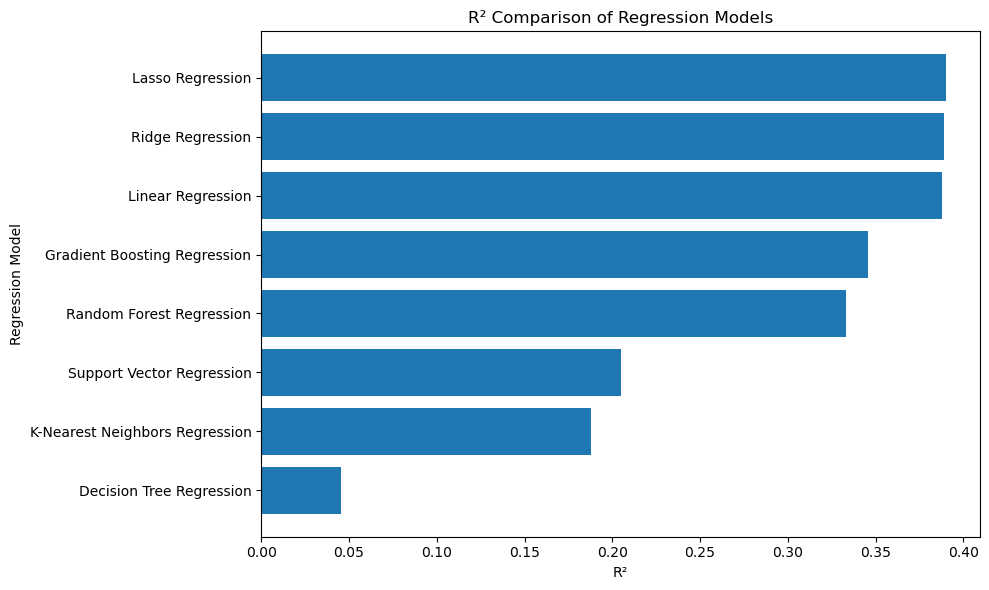

In [53]:
# ============================================================
# STEP 33A: R² COMPARISON
# ============================================================

plot_df = final_results.sort_values(
    by="R2",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["Model"],
    plot_df["R2"]
)

plt.xlabel("R²")
plt.ylabel("Regression Model")
plt.title("R² Comparison of Regression Models")

plt.tight_layout()
plt.show()

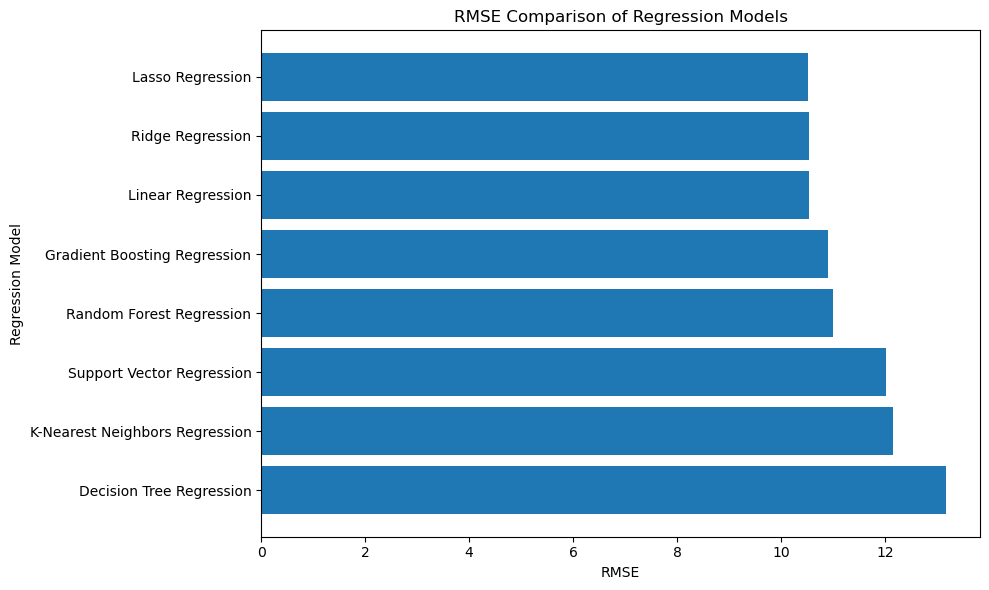

In [54]:
# ============================================================
# STEP 33B: RMSE COMPARISON
# ============================================================

plot_df = final_results.sort_values(
    by="RMSE",
    ascending=False
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["Model"],
    plot_df["RMSE"]
)

plt.xlabel("RMSE")
plt.ylabel("Regression Model")
plt.title("RMSE Comparison of Regression Models")

plt.tight_layout()
plt.show()

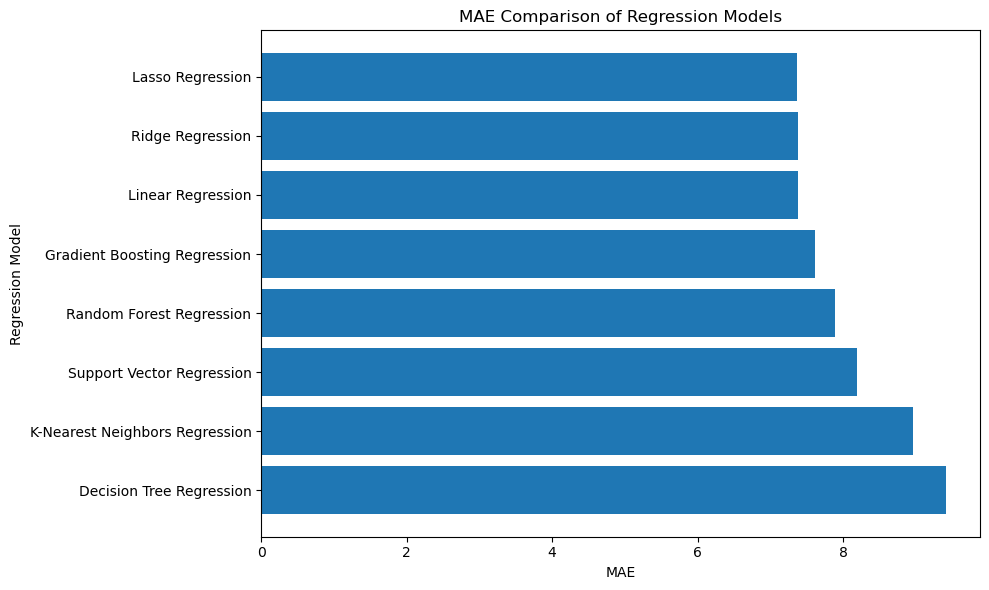

In [55]:
# ============================================================
# STEP 33C: MAE COMPARISON
# ============================================================

plot_df = final_results.sort_values(
    by="MAE",
    ascending=False
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["Model"],
    plot_df["MAE"]
)

plt.xlabel("MAE")
plt.ylabel("Regression Model")
plt.title("MAE Comparison of Regression Models")

plt.tight_layout()
plt.show()

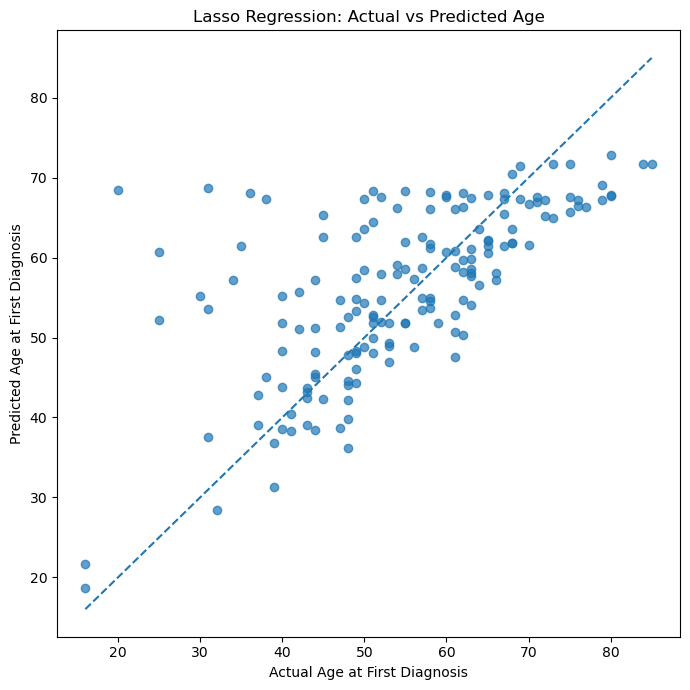

In [56]:
# ============================================================
# STEP 34: ACTUAL VS PREDICTED - LASSO
# ============================================================

lasso_predictions = predictions["Lasso Regression"]

plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    lasso_predictions,
    alpha=0.7
)

# Reference line: perfect prediction
min_value = min(y_test.min(), lasso_predictions.min())
max_value = max(y_test.max(), lasso_predictions.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Age at First Diagnosis")
plt.ylabel("Predicted Age at First Diagnosis")
plt.title("Lasso Regression: Actual vs Predicted Age")

plt.tight_layout()
plt.show()

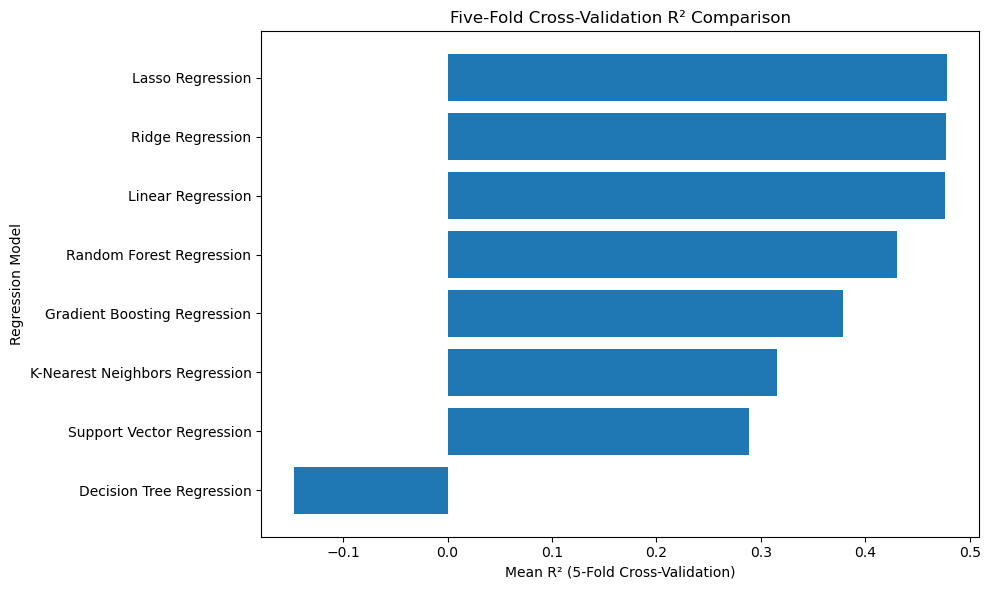

In [57]:
# ============================================================
# STEP 35: CROSS-VALIDATION R² COMPARISON
# ============================================================

plot_df = cv_results_df.sort_values(
    by="CV Mean R2",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["Model"],
    plot_df["CV Mean R2"]
)

plt.xlabel("Mean R² (5-Fold Cross-Validation)")
plt.ylabel("Regression Model")
plt.title("Five-Fold Cross-Validation R² Comparison")

plt.tight_layout()
plt.show()

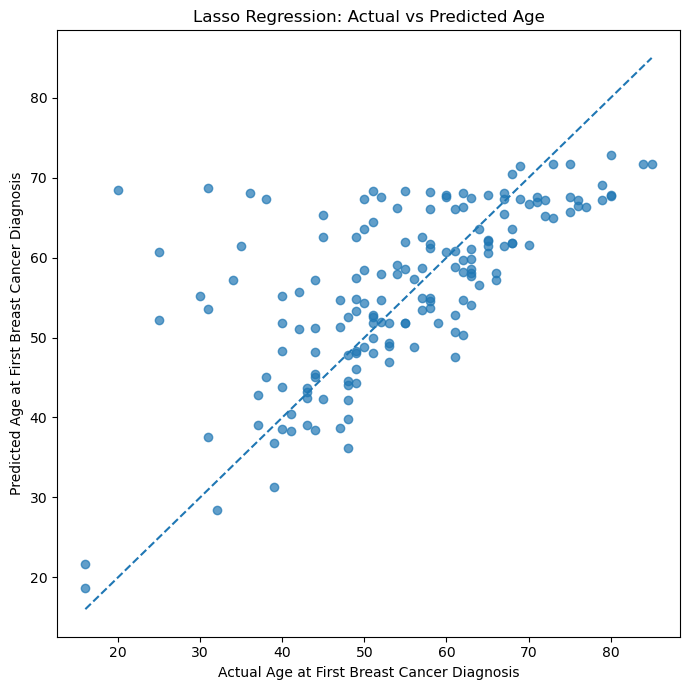

Figure saved successfully.


In [58]:
# ============================================================
# STEP 36: FINAL LASSO ACTUAL VS PREDICTED GRAPH
# ============================================================

lasso_predictions = predictions["Lasso Regression"]

plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    lasso_predictions,
    alpha=0.7
)

min_value = min(y_test.min(), lasso_predictions.min())
max_value = max(y_test.max(), lasso_predictions.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Age at First Breast Cancer Diagnosis")
plt.ylabel("Predicted Age at First Breast Cancer Diagnosis")
plt.title("Lasso Regression: Actual vs Predicted Age")

plt.tight_layout()

plt.savefig(
    "Figure_Lasso_Actual_vs_Predicted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved successfully.")

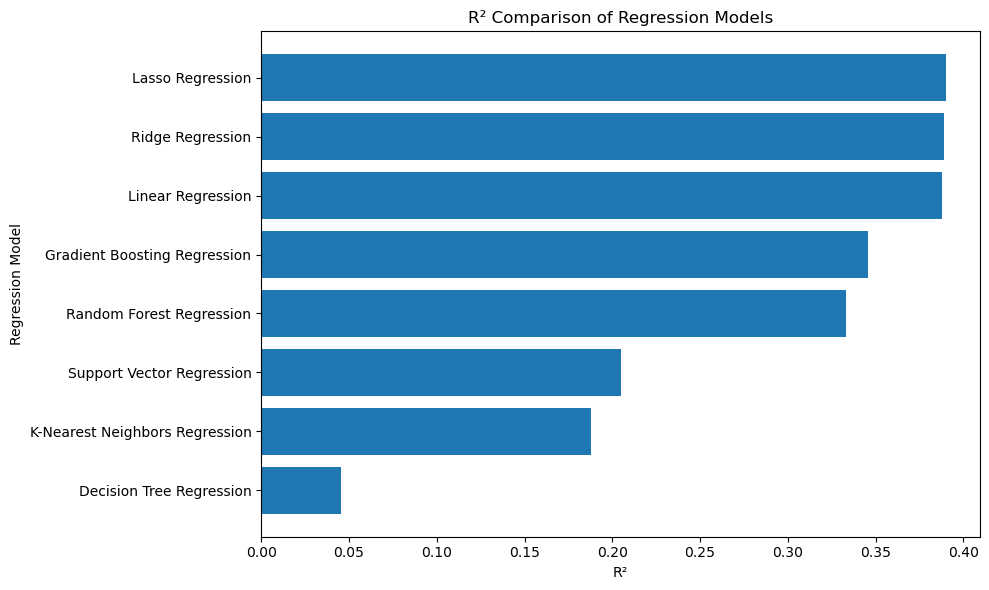

R² comparison figure saved successfully.


In [59]:
# ============================================================
# STEP 37: SAVE R² COMPARISON GRAPH
# ============================================================

plot_df = final_results.sort_values(
    by="R2",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["Model"],
    plot_df["R2"]
)

plt.xlabel("R²")
plt.ylabel("Regression Model")
plt.title("R² Comparison of Regression Models")

plt.tight_layout()

plt.savefig(
    "Figure_R2_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("R² comparison figure saved successfully.")

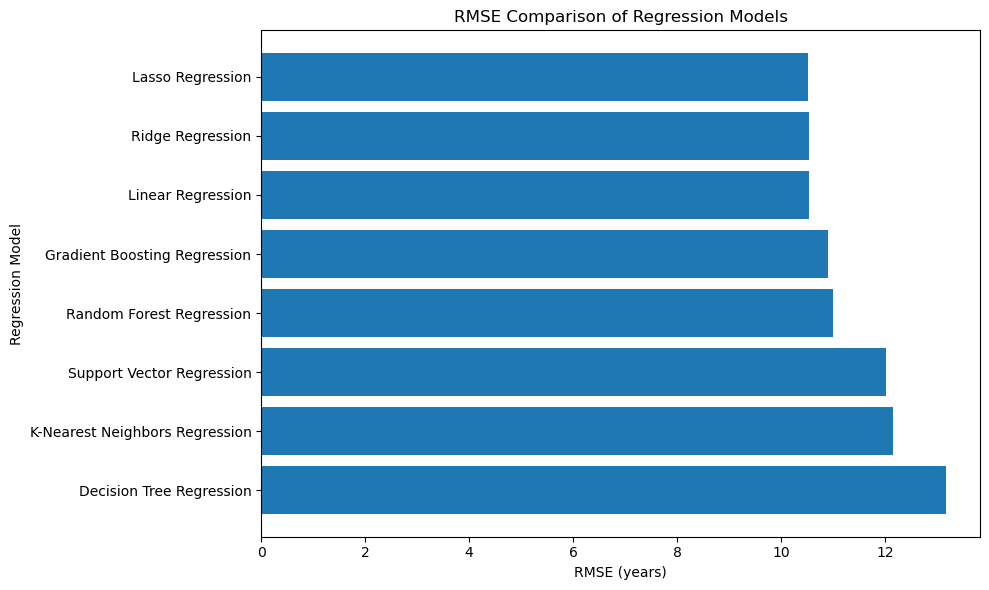

RMSE comparison figure saved successfully.


In [60]:
# ============================================================
# STEP 38: SAVE RMSE COMPARISON GRAPH
# ============================================================

plot_df = final_results.sort_values(
    by="RMSE",
    ascending=False
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["Model"],
    plot_df["RMSE"]
)

plt.xlabel("RMSE (years)")
plt.ylabel("Regression Model")
plt.title("RMSE Comparison of Regression Models")

plt.tight_layout()

plt.savefig(
    "Figure_RMSE_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("RMSE comparison figure saved successfully.")

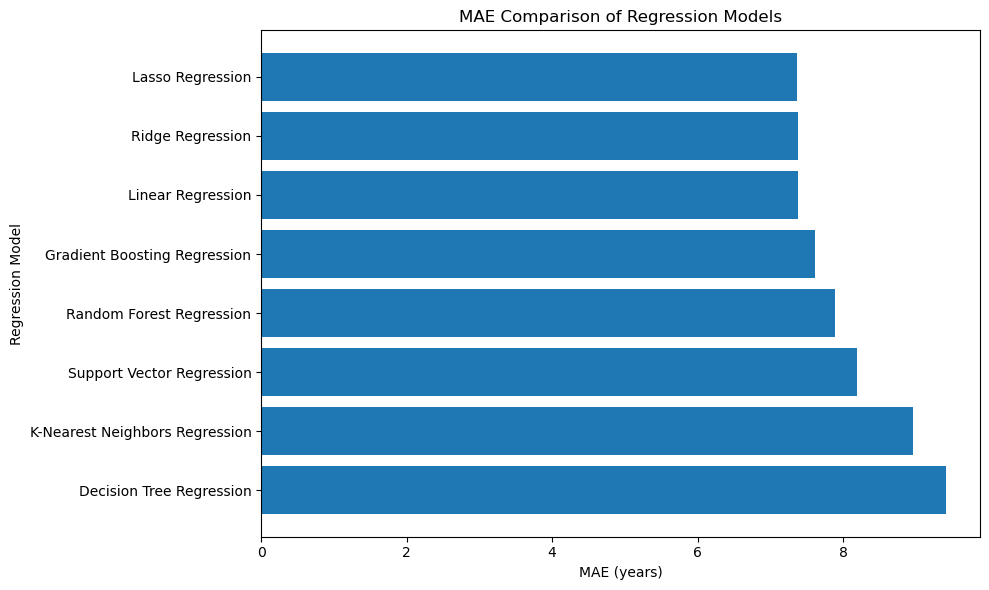

MAE comparison figure saved successfully.


In [61]:
# ============================================================
# STEP 39: SAVE MAE COMPARISON GRAPH
# ============================================================

plot_df = final_results.sort_values(
    by="MAE",
    ascending=False
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["Model"],
    plot_df["MAE"]
)

plt.xlabel("MAE (years)")
plt.ylabel("Regression Model")
plt.title("MAE Comparison of Regression Models")

plt.tight_layout()

plt.savefig(
    "Figure_MAE_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("MAE comparison figure saved successfully.")

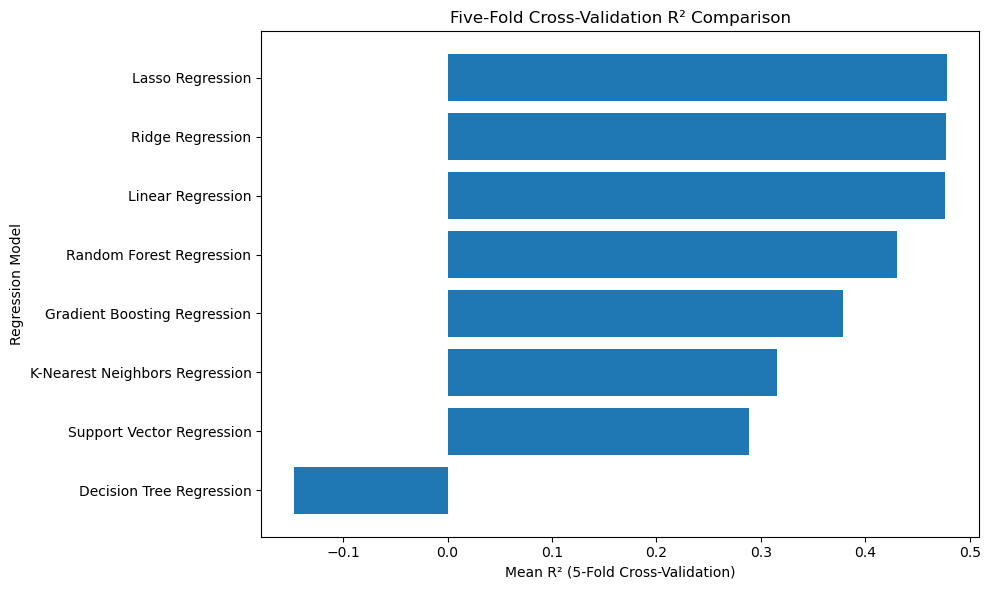

Cross-validation figure saved successfully.


In [62]:
# ============================================================
# STEP 40: SAVE CROSS-VALIDATION R² GRAPH
# ============================================================

plot_df = cv_results_df.sort_values(
    by="CV Mean R2",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df["Model"],
    plot_df["CV Mean R2"]
)

plt.xlabel("Mean R² (5-Fold Cross-Validation)")
plt.ylabel("Regression Model")
plt.title("Five-Fold Cross-Validation R² Comparison")

plt.tight_layout()

plt.savefig(
    "Figure_CV_R2_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Cross-validation figure saved successfully.")

## Final Results and Interpretation

The eight regression models were evaluated using the same held-out test set of 163 observations. Lasso Regression achieved the strongest overall performance, with a test-set MAE of 7.3641 years, MSE of 110.8524, RMSE of 10.5286 years, R² of 0.3899, MAPE of 16.9118%, and Explained Variance of 0.4064. The project-defined MAPE-derived score was 83.0882%. Lasso Regression also achieved the highest mean R² during five-fold cross-validation, with a value of 0.4780 and a standard deviation of 0.0829.

Ridge Regression and Linear Regression performed very similarly to Lasso Regression, with test-set R² values of 0.3887 and 0.3876, respectively. Gradient Boosting Regression and Random Forest Regression followed with R² values of 0.3459 and 0.3330. Support Vector Regression and K-Nearest Neighbors Regression produced lower R² values, while Decision Tree Regression showed the weakest performance. The consistent ranking of Lasso Regression across both the held-out test set and five-fold cross-validation supports its selection as the best-performing model in this experiment.

Although Lasso Regression performed best among the evaluated models, its test-set R² of 0.3899 indicates that a substantial proportion of variation in age at first breast cancer diagnosis remains unexplained. Therefore, the model should be interpreted as a comparative machine-learning result rather than as a clinically validated prediction system.

## Limitations

This study has several limitations. The analysis was based on 815 breast cancer observations with a valid recorded age at first diagnosis, which represents only the subset of NHANES participants meeting the study criteria. The selected predictors were limited to demographic, socioeconomic, and mortality-related variables available in the prepared dataset. Important clinical factors such as tumour characteristics, cancer stage, treatment history, family history, genetic information, and detailed clinical measurements were not included.

The study used an 80:20 train-test split together with five-fold cross-validation rather than an independent external validation dataset. Although cross-validation provided an additional assessment of model performance, the findings may not generalize to other populations or datasets. In addition, current age and mortality follow-up variables have temporal relationships with the diagnosis history and should therefore not be interpreted as independent causal predictors of age at diagnosis.

The MAPE-derived score reported in this project is calculated from MAPE and should not be interpreted as classification accuracy or as the percentage of patients for whom the predicted age was exactly correct. Finally, the moderate test-set R² indicates that considerable variation in the target remains unexplained. Further studies using larger datasets, additional clinical predictors, and independent validation would be required before considering the approach for practical or clinical application.

## Future Scope

Future work could incorporate additional clinical, behavioural, environmental, and family-history variables where appropriate data are available. Larger and more diverse datasets could also improve the generalizability of the findings. Independent external validation would provide a stronger assessment of model performance. Further experiments could investigate feature-selection methods, hyperparameter optimization, regularization techniques, and additional ensemble models. Future studies should also examine whether clinically meaningful predictors improve the estimation of age at first breast cancer diagnosis while maintaining appropriate validation and avoiding information leakage.

## Conclusion

This study compared eight machine-learning regression algorithms for estimating age at first breast cancer diagnosis using selected variables from the NHANES dataset. Lasso Regression achieved the strongest overall performance among the evaluated models on the held-out test set and also obtained the highest mean R² during five-fold cross-validation. It achieved a test-set MAE of 7.3641 years, RMSE of 10.5286 years, and R² of 0.3899.

The findings indicate that the selected variables contain useful information for estimating age at first diagnosis, but the moderate R² also shows that substantial variation remains unexplained. Therefore, Lasso Regression can be considered the best-performing model within this experimental framework, but the results should not be interpreted as evidence of a clinically validated prediction system. Additional clinical predictors, larger datasets, and independent validation would be needed to determine whether the approach can provide reliable predictions in broader populations.